#Tutorial 2 Multi-Layer Perceptron (MLP) for Genomic Data Analysis

This notebook demonstrates how to build and tune an MLP classifier. We will explore:
1. Model architecture (layers and neurons).
2. Optimization (learning rates).
3. Performance evaluation using accuracy and learning curves.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Loading a dataset - using California housing as a structural proxy for genomic features
# In a real scenario, you would load your RA genomic CSV here.
raw_data = pd.read_csv('/content/sample_data/california_housing_train.csv')

# Simulate a binary classification task for Rheumatoid Arthritis (RA) status
# We'll create a target based on the median house value for demonstration
df = raw_data.copy()
df['RA_Status'] = (df['median_house_value'] > df['median_house_value'].median()).astype(int)
X = df.drop(['median_house_value', 'RA_Status'], axis=1)
y = df['RA_Status']

# Step 1: Data Preprocessing
# Neural networks are sensitive to feature scaling.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f'Training set size: {X_train.shape}')
print(f'Testing set size: {X_test.shape}')

Training set size: (13600, 8)
Testing set size: (3400, 8)


### Task 1: Modifying Hidden Layers and Neurons
We will compare a simple model (one hidden layer) against a deeper model to see the effect on accuracy.

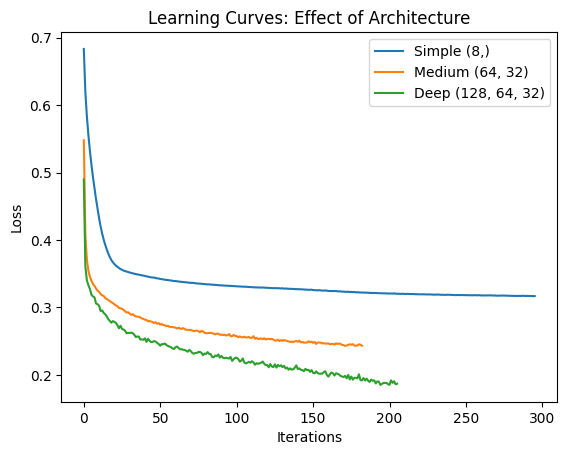

,Architecture,Accuracy,Loss
0,"Simple (8,)",0.860000,0.316872
1,"Medium (64, 32)",0.884118,0.243367
2,"Deep (128, 64, 32)",0.883235,0.187067


In [ ]:
architectures = [
    {'name': 'Simple (8,)', 'layers': (8,)},
    {'name': 'Medium (64, 32)', 'layers': (64, 32)},
    {'name': 'Deep (128, 64, 32)', 'layers': (128, 64, 32)}
]

results = []

for arch in architectures:
    mlp = MLPClassifier(hidden_layer_sizes=arch['layers'], max_iter=500, random_state=42)
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Architecture': arch['name'], 'Accuracy': acc, 'Loss': mlp.loss_})

    plt.plot(mlp.loss_curve_, label=arch['name'])

plt.title('Learning Curves: Effect of Architecture')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

display(pd.DataFrame(results))

### Task 2: Changing the Learning Rate
The learning rate controls how much we update the weights at each step. High rates might overshoot; low rates might take too long to converge.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


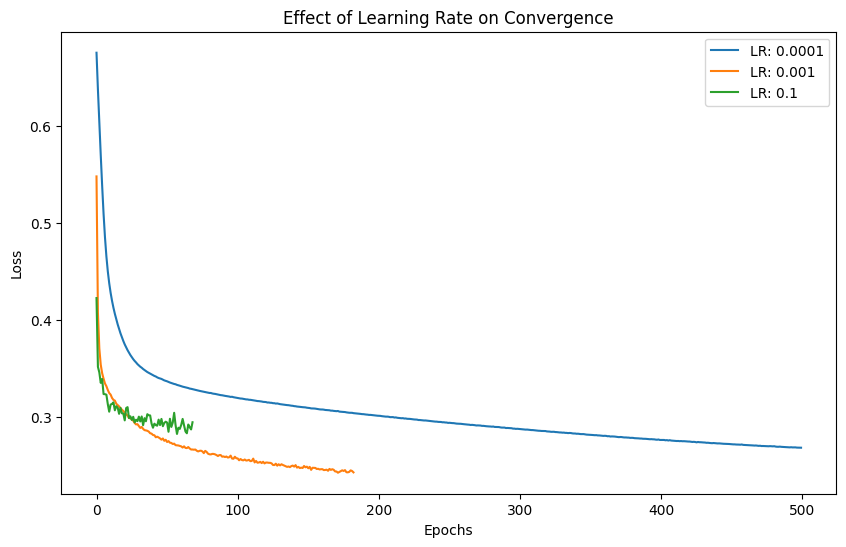

In [ ]:
learning_rates = [0.0001, 0.001, 0.1]
plt.figure(figsize=(10, 6))

for lr in learning_rates:
    mlp = MLPClassifier(hidden_layer_sizes=(64, 32), learning_rate_init=lr, max_iter=500, random_state=42)
    mlp.fit(X_train, y_train)
    plt.plot(mlp.loss_curve_, label=f'LR: {lr}')

plt.title('Effect of Learning Rate on Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()